present -> raw/present\bio\bio_1
holocene -> raw/mid_holocene\ccmidbi1.tif
lgm -> raw/lgm\cclgmbi1.tif
present min -23.7 max 30.8 mean 8.2
holocene min -24.5 max 29.7 mean 7.1
lgm min -37.1 max 30.6 mean -2.0


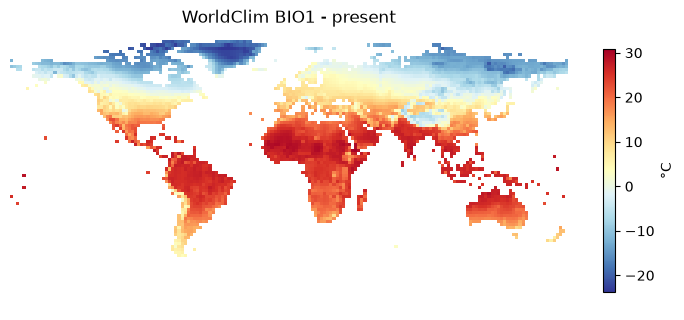

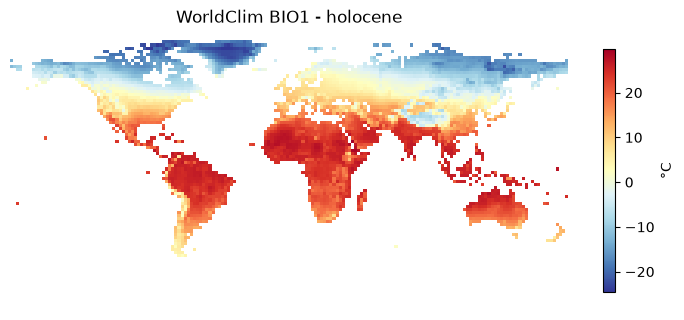

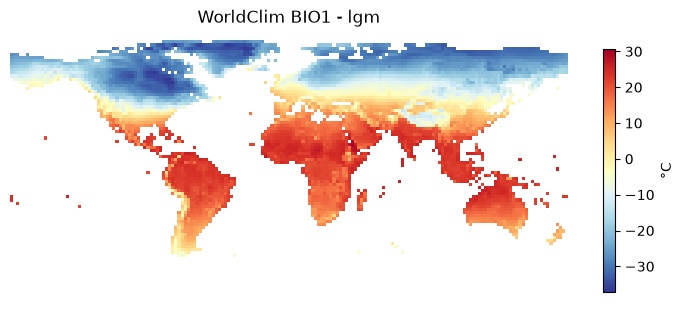

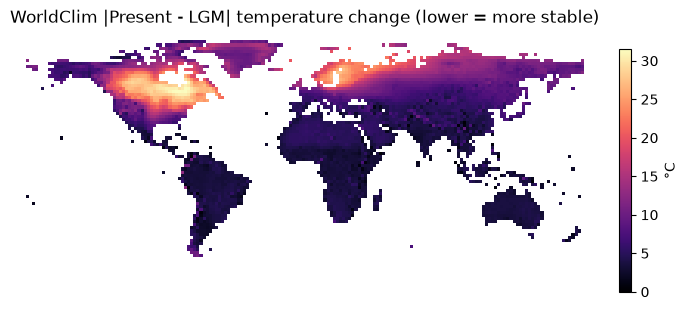

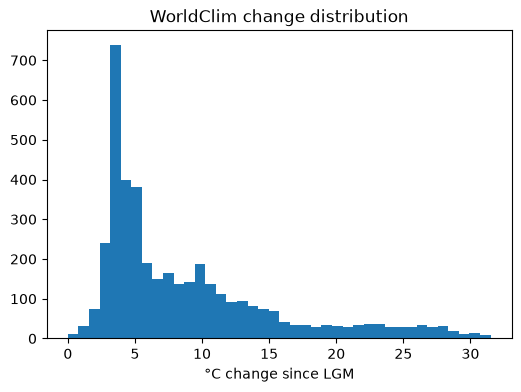

(374, 8)


,cell_lat,cell_lon,wc_present,wc_holocene,wc_lgm,wc_lgm_change,wc_holo_change,wc_instability
0,-52.5,-72.5,6.020000,5.200000,-3.810000,9.830000,0.820000,5.454387
1,-52.5,-67.5,4.157895,3.436842,-6.478947,10.636842,0.721053,5.944020
2,-52.5,167.5,7.600000,7.100000,4.700000,2.900000,0.500000,1.550269
3,-47.5,-72.5,4.987500,4.150000,-3.112500,8.100000,0.837500,4.455160
4,-47.5,167.5,8.566667,7.883333,4.983333,3.583333,0.683333,1.902732


In [1]:
import sys
sys.path.append("..")

from common.helpers import *
import zipfile


# Unzip only if the folders are empty
for z, d in [
    ("cclgmbi_10m.zip", "lgm"),
    ("ccmidbi_10m.zip", "mid_holocene"),
    ("bio_10m_esri.zip", "present")
]:
    os.makedirs(f"raw/{d}", exist_ok=True)

    if not glob.glob(f"raw/{d}/*"):
        zipfile.ZipFile(f"raw/{z}").extractall(f"raw/{d}")


W = {
    "present": find_bio1("raw/present"),
    "holocene": find_bio1("raw/mid_holocene"),
    "lgm": find_bio1("raw/lgm")
}

for k, v in W.items():
    print(k, "->", v)   # check these are the BIO1 files


pts = pd.read_csv(
    "../GBIF/processed/gbif_points_clean.csv"
)

grids = {
    k: global_grid(v)
    for k, v in W.items()
}


# Sanity check: values should be roughly -50 to 35 °C
for k, g in grids.items():
    print(
        k,
        "min", np.nanmin(g).round(1),
        "max", np.nanmax(g).round(1),
        "mean", np.nanmean(g).round(1)
    )


for k, g in grids.items():
    plot_map(
        g,
        f"WorldClim BIO1 - {k}",
        "°C",
        f"figures/wc_bio1_{k}.png",
        "RdYlBu_r"
    )


diff = np.abs(
    grids["present"] - grids["lgm"]
)

plot_map(
    diff,
    "WorldClim |Present - LGM| temperature change (lower = more stable)",
    "°C",
    "figures/wc_lgm_change.png",
    "magma"
)

np.save(
    "processed/wc_lgm_change_2deg.npy",
    diff
)


plt.figure(figsize=(6, 4))

plt.hist(
    diff[~np.isnan(diff)],
    bins=40
)

plt.xlabel("°C change since LGM")
plt.title("WorldClim change distribution")

plt.savefig(
    "figures/wc_change_hist.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Table 1: summary of the three periods
pd.DataFrame({
    k: pd.Series(v.ravel()).describe()
    for k, v in grids.items()
}).round(2).to_csv(
    "processed/wc_summary.csv"
)


# Table 2: cell-level stability for GBIF cells
cells = cell_climate(
    W,
    pts,
    "wc"
)

cells.to_csv(
    "processed/worldclim_cell_stability.csv",
    index=False
)

cells.describe().round(2).to_csv(
    "processed/wc_cell_stats.csv"
)

print(cells.shape)
cells.head()

In [2]:
# ---------- Numbers for notes.md ----------

print("Grid:", CELL, "degrees")
print(
    "GBIF points:", len(pts),
    "| cells with climate values:", len(cells)
)


print("\nGlobal BIO1 by period (2° display grid, °C):")
print(
    pd.read_csv(
        "processed/wc_summary.csv",
        index_col=0
    ).loc[
        ["min", "max", "mean"]
    ].to_string()
)


print("\nCell-level climate (mean over GBIF cells, °C):")
print(
    cells[
        ["wc_present", "wc_holocene", "wc_lgm"]
    ].agg(
        ["min", "median", "mean", "max"]
    ).round(1).to_string()
)


print("\nStability metrics across cells:")
print(
    cells[
        ["wc_lgm_change", "wc_holo_change", "wc_instability"]
    ].agg(
        ["min", "median", "mean", "max"]
    ).round(2).to_string()
)


q1, q3 = cells.wc_lgm_change.quantile([.25, .75])

print(
    "\nLGM change quartiles: Q1 =", round(q1, 1),
    "| Q3 =", round(q3, 1)
)

print(
    "Cells with LGM change < 10 °C (stable):",
    int((cells.wc_lgm_change < 10).sum()),
    "| 10-20 °C:",
    int(cells.wc_lgm_change.between(10, 20).sum()),
    "| > 20 °C (unstable):",
    int((cells.wc_lgm_change > 20).sum())
)

print(
    "Cells with Holocene change < 1 °C:",
    int((cells.wc_holo_change < 1).sum()),
    "of", len(cells)
)


cols = [
    "cell_lat",
    "cell_lon",
    "wc_present",
    "wc_lgm",
    "wc_lgm_change"
]


print("\n10 MOST stable cells (lowest LGM change):")
print(
    cells.sort_values(
        "wc_lgm_change"
    ).head(10)[cols].round(1).to_string(index=False)
)


print("\n10 LEAST stable cells (highest LGM change):")
print(
    cells.sort_values(
        "wc_lgm_change",
        ascending=False
    ).head(10)[cols].round(1).to_string(index=False)
)


print("\nMean LGM change by latitude band:")
print(
    cells.groupby(
        cells.cell_lat.round(-1)
    ).wc_lgm_change.agg(
        ["mean", "count"]
    ).round(1).to_string()
)


print(
    "\nCorrelation between LGM change and |latitude|:",
    round(
        spearmanr(
            cells.wc_lgm_change,
            cells.cell_lat.abs()
        )[0],
        2
    )
)


# Agreement with PaleoClim at cell level
pcc = pd.read_csv(
    "../PALEOCLIM/processed/paleoclim_cell_stability.csv"
)

m = cells.merge(
    pcc,
    on=["cell_lat", "cell_lon"]
)

print(
    "\nCells in both datasets:", len(m),
    "| Spearman (LGM change, WorldClim vs PaleoClim):",
    round(
        spearmanr(
            m.wc_lgm_change,
            m.pc_lgm_change
        )[0],
        2
    )
)

print(
    "Mean LGM change -> WorldClim:",
    round(m.wc_lgm_change.mean(), 2),
    "| PaleoClim:",
    round(m.pc_lgm_change.mean(), 2)
)

Grid: 5 degrees
GBIF points: 17396 | cells with climate values: 374

Global BIO1 by period (2° display grid, °C):
      present  holocene    lgm
min    -23.70    -24.50 -37.10
max     30.80     29.70  30.60
mean     8.15      7.09  -2.03

Cell-level climate (mean over GBIF cells, °C):
        wc_present  wc_holocene  wc_lgm
min           -6.8         -8.5   -28.5
median        18.7         17.9    14.5
mean          17.1         16.3    10.7
max           28.5         27.4    25.8

Stability metrics across cells:
        wc_lgm_change  wc_holo_change  wc_instability
min              1.60            0.00            0.82
median           3.85            0.78            2.02
mean             6.47            0.83            3.55
max             27.60            2.43           15.65

LGM change quartiles: Q1 = 3.3 | Q3 = 6.5
Cells with LGM change < 10 °C (stable): 314 | 10-20 °C: 31 | > 20 °C (unstable): 29
Cells with Holocene change < 1 °C: 281 of 374

10 MOST stable cells (lowest LGM chan